In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Columns in dataset:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset shape: (541909, 8)

Missing values bef

/tmp/ipykernel_524/1698392929.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HighValuePurchase', data=df, palette='viridis')


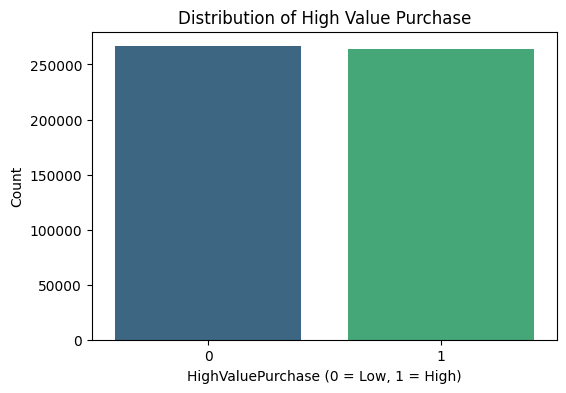

/tmp/ipykernel_524/1698392929.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')


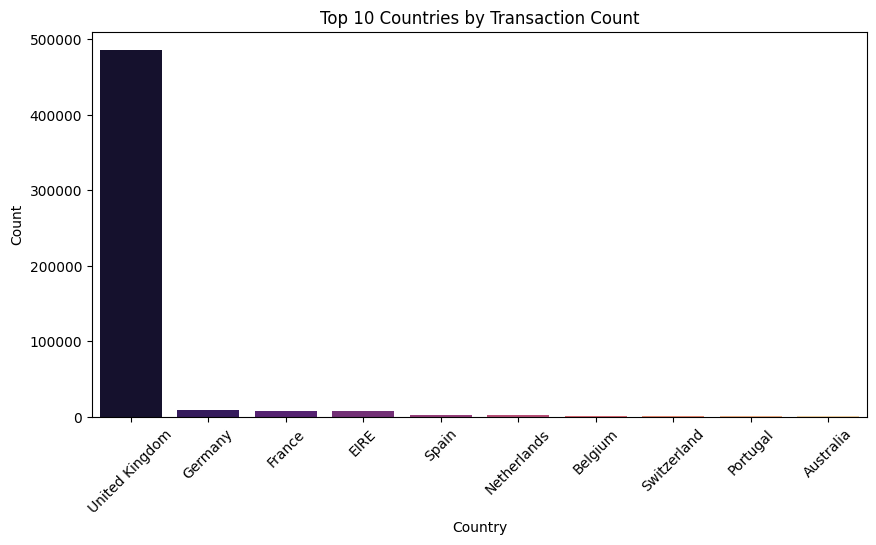


Accuracy Scores:
Logistic Regression: 0.8501428962186737
Decision Tree: 0.9743164090133087
KNN: 0.9992360004150121

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.87      0.85     53289
           1       0.86      0.83      0.85     52732

    accuracy                           0.85    106021
   macro avg       0.85      0.85      0.85    106021
weighted avg       0.85      0.85      0.85    106021


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     53289
           1       0.96      0.99      0.97     52732

    accuracy                           0.97    106021
   macro avg       0.97      0.97      0.97    106021
weighted avg       0.97      0.97      0.97    106021


Classification Report - KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53289
        

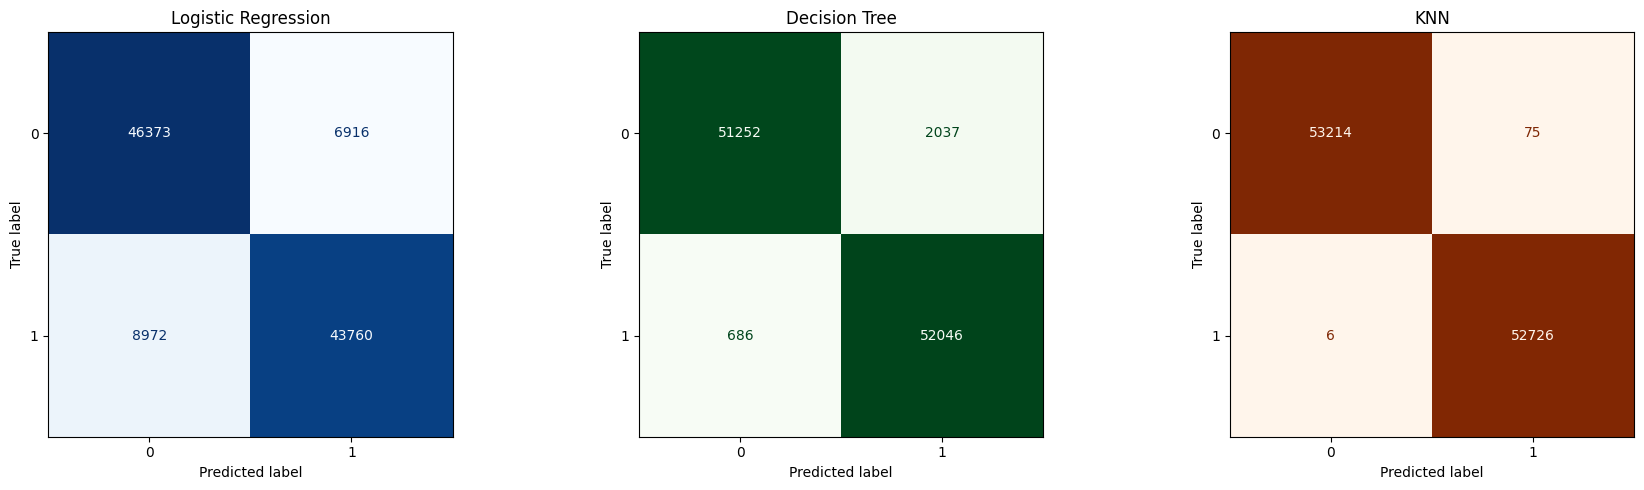

/tmp/ipykernel_524/1698392929.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Set2')


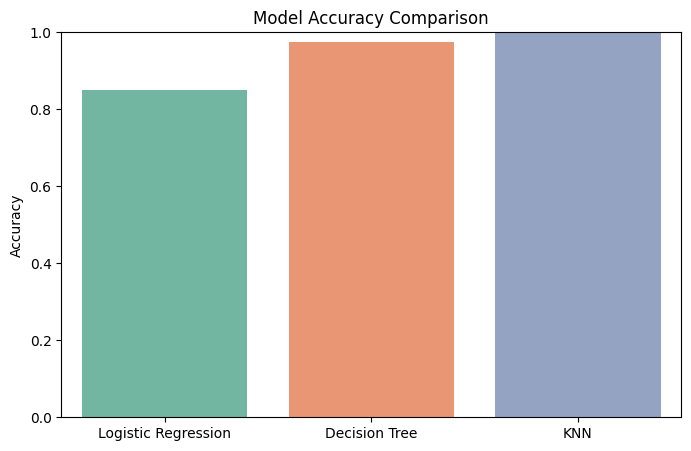

In [ ]:
# Final ML Project
# Compare Logistic Regression, Decision Tree, and KNN
# Dataset: UCI Online Retail (.xlsx).(https://archive.ics.uci.edu/dataset/352/online+retail)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# -----------------------------
# 1. Load Dataset from Excel
# -----------------------------
# Keep the Excel file in the same folder as your script/notebook
file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)

print("First 5 rows:")
print(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

# -----------------------------
# 2. Select Required Features
# -----------------------------
df = df[['Quantity', 'UnitPrice', 'Country']].copy()

# -----------------------------
# 3. Handle Missing Values
# -----------------------------
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df.dropna(inplace=True)

# Remove rows with invalid values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("\nDataset shape after cleaning:", df.shape)

# -----------------------------
# 4. Create Target Variable
# -----------------------------
# Revenue = Quantity * UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Create binary classification target
median_revenue = df['Revenue'].median()
df['HighValuePurchase'] = np.where(df['Revenue'] > median_revenue, 1, 0)

print("\nTarget class distribution:")
print(df['HighValuePurchase'].value_counts())

# -----------------------------
# 5. Encode Country
# -----------------------------
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])

# -----------------------------
# 6. Visualize Data
# -----------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x='HighValuePurchase', data=df, palette='viridis')
plt.title("Distribution of High Value Purchase")
plt.xlabel("HighValuePurchase (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='magma')
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 7. Features and Target
# -----------------------------
X = df[['Quantity', 'UnitPrice', 'Country_Encoded']]
y = df['HighValuePurchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 8. Train Models
# -----------------------------
log_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train, y_train)
knn_model.fit(X_train_scaled, y_train)

# -----------------------------
# 9. Predictions
# -----------------------------
y_pred_log = log_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)

# -----------------------------
# 10. Evaluation
# -----------------------------
acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("\nAccuracy Scores:")
print("Logistic Regression:", acc_log)
print("Decision Tree:", acc_dt)
print("KNN:", acc_knn)

print("\nClassification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_pred_dt))

print("\nClassification Report - KNN")
print(classification_report(y_test, y_pred_knn))

# -----------------------------
# 11. Confusion Matrices
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title("KNN")

plt.tight_layout()
plt.show()

# -----------------------------
# 12. Accuracy Comparison Graph
# -----------------------------
model_names = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [acc_log, acc_dt, acc_knn]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='Set2')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()